# Data Quality Profiling

This notebook checks missingness, duplicates, negative demand, zero-demand periods, and IQR outliers.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import Image, Markdown, display
except Exception:
    def display(value):
        print(value)
    def Markdown(text):
        return text
    class Image:
        def __init__(self, filename=None, **kwargs):
            self.filename = filename
        def __repr__(self):
            return f"Image(filename={self.filename!r})"

ROOT = Path.cwd()
if ROOT.name != "v7_rm_pm_forecast_planning":
    ROOT = Path("Ai miroservices/modeling/v7_rm_pm_forecast_planning").resolve()
OUT = ROOT / "outputs"
PLOTS = OUT / "plots"
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

def load_csv(name, **kwargs):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return pd.read_csv(path, **kwargs)

def load_json(name):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return json.loads(path.read_text())

def show_plot(name):
    path = PLOTS / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"Plot not generated: `{path}`"))

In [2]:
quality = load_csv('data_quality_report.csv')
quality

,dataset,rows,columns,duplicate_rows,total_null_cells,null_cell_pct
0,material_inventory_snapshot,291,18,0,0,0.000000
1,material_type_counts,2,2,0,0,0.000000
2,monthly_demand_panel,10368,11,0,0,0.000000
3,demand_classification,288,18,0,0,0.000000
4,bom_coverage_audit,4,12,0,16,0.333333
5,existing_forecast_results_snapshot,6102,16,0,12204,0.125000
6,forecast_results_v7,3456,13,0,0,0.000000
7,inventory_policy_recommendations_v7,288,40,0,0,0.000000
8,slotting_readiness_v7,288,16,0,0,0.000000


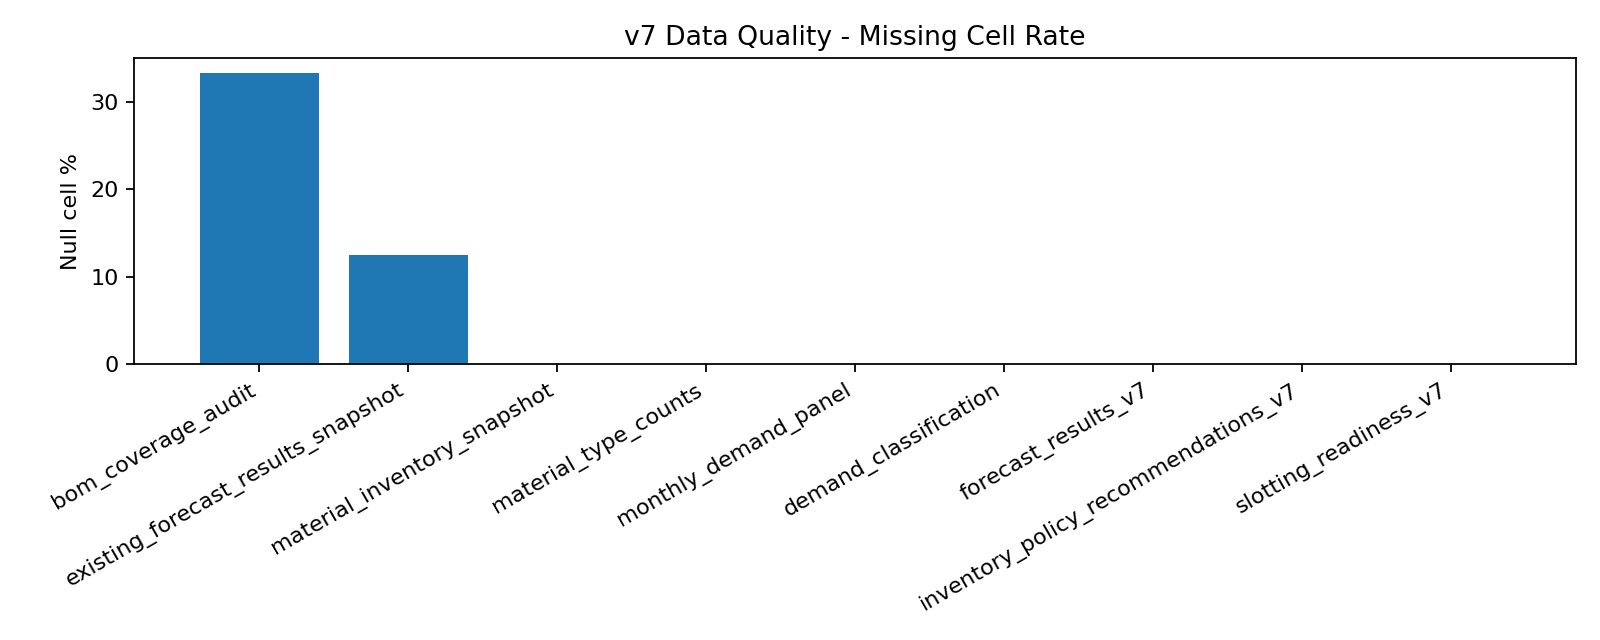

In [3]:
show_plot('data_quality_missingness.png')

In [4]:
outliers = load_csv("outlier_report.csv")
outliers.head(30)

,material_id,material_code,description,material_type,months,zero_months,negative_months,iqr_lower_bound,iqr_upper_bound,outlier_months,max_demand
0,68a83668-10c4-41dc-bafd-084ee15603d8,100527,CARBOPOL AQUA SF - 1,raw_material,36,0,0,211.375,304.375,9,336.0
1,c6b5f46c-d78d-4d79-be56-0b06ac6a5c38,101503,KOH,raw_material,36,0,0,109.250,319.250,8,279.0
2,a82160bf-b7aa-49a6-ab75-b6a92485b4c5,101379,ACUSOL 445 N,raw_material,36,0,0,7.875,20.875,8,23.0
3,5620b6a5-39c6-47f3-a599-d135b0333fcb,101378,LUTENSOL TO 8,raw_material,36,0,0,75.500,151.500,7,215.0
4,dcf2ce87-e426-487a-a765-9ea60d1f67eb,101576,OPTAMINT 701655,raw_material,36,0,0,13.750,81.750,7,103.0
5,c5b3f631-d4f4-4c70-a300-9eebe5ba85c3,100090,SALCARE 91,raw_material,36,0,0,40.125,61.125,7,63.0
6,82882db6-2c73-4f0e-bf19-0aa081054e55,100072,MICROCRYSTALLINE WAX,raw_material,36,0,0,54.000,88.000,6,85.0
7,4c9295da-d694-4618-b94e-73c129de5b68,101223,INNOVATION AR 285118,raw_material,36,0,0,1.375,10.375,6,13.0
8,6d0c240f-19ff-4f1f-bc9f-0d4902497e0b,101505,MYRISTIC ACID,raw_material,36,0,0,204.000,342.000,5,414.0
9,e62e5a61-0734-4b75-82ec-5c3514d37898,100134,ZINC OXIDE,raw_material,36,0,0,165.750,299.750,5,315.0


In [5]:
outliers.agg(
    materials=("material_id", "count"),
    materials_with_outliers=("outlier_months", lambda s: int((s > 0).sum())),
    total_outlier_months=("outlier_months", "sum"),
    negative_months=("negative_months", "sum"),
    zero_months=("zero_months", "sum"),
)

,material_id,outlier_months,negative_months,zero_months
materials,288.0,NaN,NaN,NaN
materials_with_outliers,NaN,145.0,NaN,NaN
total_outlier_months,NaN,341.0,NaN,NaN
negative_months,NaN,NaN,0.0,NaN
zero_months,NaN,NaN,NaN,1567.0


In [6]:
demand = load_csv("monthly_demand_panel.csv", parse_dates=["month"])
demand[["demand_units"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,demand_units
count,10368.000000
mean,1886.738812
std,9128.616749
min,0.000000
1%,0.000000
5%,0.000000
25%,4.000000
50%,49.000000
75%,503.250000
95%,5625.900000
